# Appendix A — t-SNE Variants: Tangent Distance, p=q Ansatz, and Multiscale Affinities

**Thesis correspondence:** Appendix A

Experimental t-SNE variants explored during thesis development:

- **Tangent Distance t-SNE** — replaces Euclidean distance in p_ij with tangent distance (invariant to small image translations)
- **p = q t-SNE** (`tsne_pq`) — uses the same Student-t kernel for p_ij and q_ij
- **Multiscale t-SNE** (`tsne_p`) — averages Gaussian affinities across multiple perplexities [5, 30, 50]
- **SD t-SNE** — stochastic direction variant from `SD_tSNE_2D`
- **Perturbation analysis** — pixel-swap robustness across MNIST, Olivetti Faces, COIL-20

In [ ]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from tsne_spectral import (
    tsne_eigen,
    get_original_pairwise_affinities,
    get_symmetric_p_ij,
    initialization,
    get_low_dimensional_affinities,
    get_gradient,
    spectral_init,
    laplacian_eigenmaps_init,
    load_mnist,
    load_coil20,
    load_olivetti,
    plot_embedding,
)
from SD_tSNE_2D import run_sd_tsne

allowed arguments for t-SNE:
- X: array
- perplexity: int
- T: int 
- eta: int 
- early_exaggeration: int 
- n_dimensions: int 

other datasets:
- swiss roll
- brown corpus (needs a fourier transform to represent it in the spectral domain)
- belkin uses a `speech` dataset, but it seems to be private, so there may be alternatives

# MNIST


In [ ]:
x_train_pca, y_train = load_mnist(n_samples=500, pca_components=30)

# Olievtti Faces

In [ ]:
X_pca_face, y_f = load_olivetti(pca_components=40)

# COIL-20

In [ ]:
coil_path = r'C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\coil-20-proc\coil-20-proc'
X_pca_coil, y_c = load_coil20(data_dir=coil_path, pca_components=40)

# t-SNE


# Core t-SNE functions imported from tsne_spectral (see top-level imports).
# The legacy `tsne()` is equivalent to `tsne_eigen(initialization_method="PCA")`.

## Example on MNIST data 

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.8403983473743648
Iteration 50: Value of Cost Function is 0.7827990077131752
Iteration 100: Value of Cost Function is 0.7003927540106564
Iteration 150: Value of Cost Function is 0.6662574303904982
Iteration 200: Value of Cost Function is 0.6534516879070803
Iteration 250: Value of Cost Function is 0.6456694689526997
Iteration 300: Value of Cost Function is 0.638297853120278
Iteration 350: Value of Cost Function is 0.6327874353852825
Iteration 400: Value of Cost Function is 0.6290448341348215
Iteration 450: Value of Cost Function is 0.6260759619472189
Iteration 500: Value of Cost Function is 0.6240270172871681
Iteration 550: Value of Cost Function is 0.6225850541100828
Iteration 600: Value of Cost Function is 0.6214098629208458
Iteration 650: Value of Cost Function 

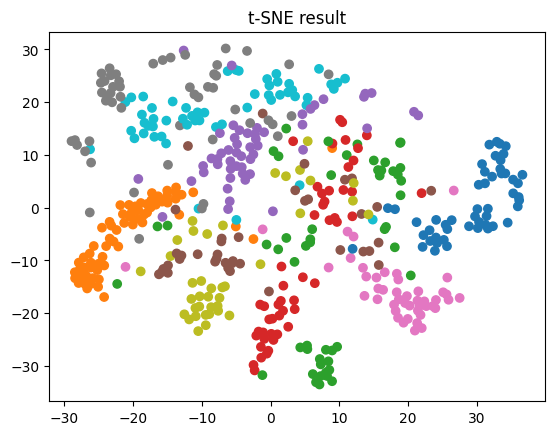

In [6]:
# Example usage:
Y = tsne(x_train_pca)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_train, cmap='tab10')
plt.title('t-SNE result')
plt.show()

## Example on Olivetti Faces

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.7348150046244843
Iteration 50: Value of Cost Function is 0.7462609105860525
Iteration 100: Value of Cost Function is 0.626801930215131
Iteration 150: Value of Cost Function is 0.5630645410346975
Iteration 200: Value of Cost Function is 0.5345047560449787
Iteration 250: Value of Cost Function is 0.5164850347747844
Iteration 300: Value of Cost Function is 0.5074526712245065
Iteration 350: Value of Cost Function is 0.4999618233113032
Iteration 400: Value of Cost Function is 0.4954795212607066
Iteration 450: Value of Cost Function is 0.4929864262092073
Iteration 500: Value of Cost Function is 0.4913235216936521
Iteration 550: Value of Cost Function is 0.4905385901079103
Iteration 600: Value of Cost Function is 0.4899270447047826
Iteration 650: Value of Cost Function 

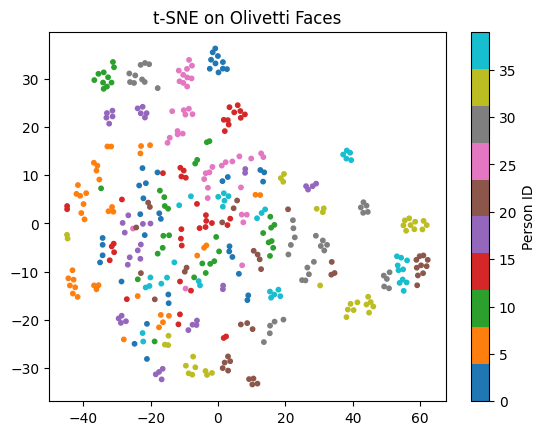

In [7]:
# Example usage:
Y = tsne(X_pca_face)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_f, cmap='tab10', s=10)
plt.colorbar(label="Person ID")
plt.title("t-SNE on Olivetti Faces")
plt.show()

## Example on COIL-20

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.582837332814827
Iteration 50: Value of Cost Function is 1.044425216380667
Iteration 100: Value of Cost Function is 0.897549304001038
Iteration 150: Value of Cost Function is 0.81894068190154
Iteration 200: Value of Cost Function is 0.7724519633100887
Iteration 250: Value of Cost Function is 0.737596470711614
Iteration 300: Value of Cost Function is 0.7107718096508946
Iteration 350: Value of Cost Function is 0.6890432182128788
Iteration 400: Value of Cost Function is 0.6714467706327119
Iteration 450: Value of Cost Function is 0.6577148579054349
Iteration 500: Value of Cost Function is 0.6445969628520244
Iteration 550: Value of Cost Function is 0.6324526408426713
Iteration 600: Value of Cost Function is 0.6219850587997845
Iteration 650: Value of Cost Function is 0.

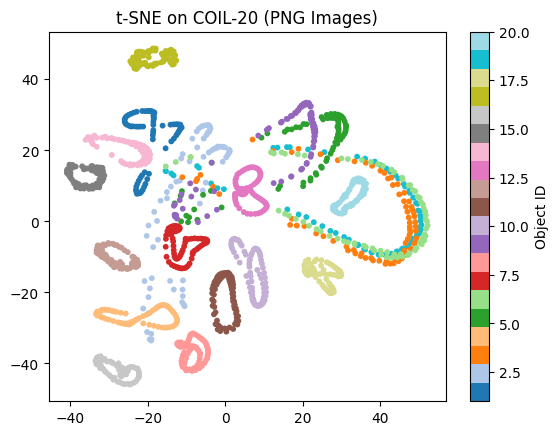

In [8]:
# Example usage:
Y = tsne(X_pca_coil)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_c, cmap='tab20', s=10)
plt.colorbar(label="Object ID")
plt.title("t-SNE on COIL-20 (PNG Images)")
plt.show()

# t-SNE with Eigenmaps an laplacian

# `spectral_init`, `laplacian_eigenmaps_init`, `tsne_eigen` — all imported from tsne_spectral.

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.8409242253495701
Iteration 50: Value of Cost Function is 3.462165270591789
Completed Low Dimensional Embedding: Final Value of Cost Function is 3.5117382169283826


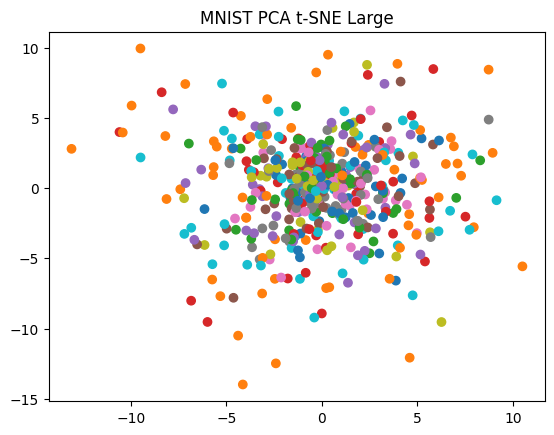

In [10]:
# Example usage:
Y = tsne_eigen(x_train_pca, initialization_method="PCA", T = 100)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_train, cmap='tab10')
plt.title('MNIST PCA t-SNE Large')
plt.show()

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.6256110598395725
Iteration 50: Value of Cost Function is 3.429278634118177
Completed Low Dimensional Embedding: Final Value of Cost Function is 3.538716643461211


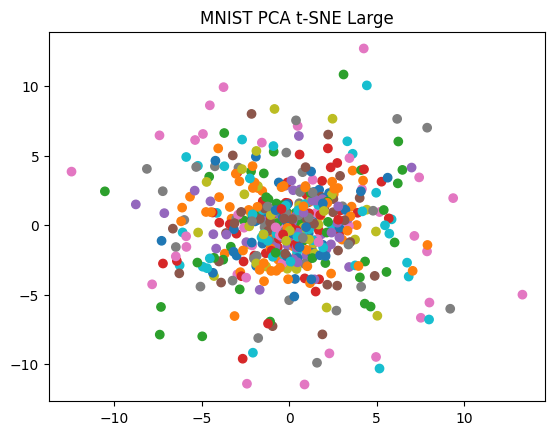

In [11]:
# Example usage:
Y = tsne_eigen(x_train_pca, initialization_method="spectral", T = 100)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_train, cmap='tab10')
plt.title('MNIST PCA t-SNE Large')
plt.show()

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 3.663671010562614
Iteration 50: Value of Cost Function is 3.5171747437328937
Iteration 100: Value of Cost Function is 3.6918697881753886
Iteration 150: Value of Cost Function is 3.8671299451008285
Iteration 200: Value of Cost Function is 3.9899703416436796
Iteration 250: Value of Cost Function is 4.046707226491954
Iteration 300: Value of Cost Function is 3.086092603109076
Iteration 350: Value of Cost Function is 2.853208592566134
Iteration 400: Value of Cost Function is 2.71059669567654
Iteration 450: Value of Cost Function is 2.6080547395987477
Completed Low Dimensional Embedding: Final Value of Cost Function is 2.5309372061415045


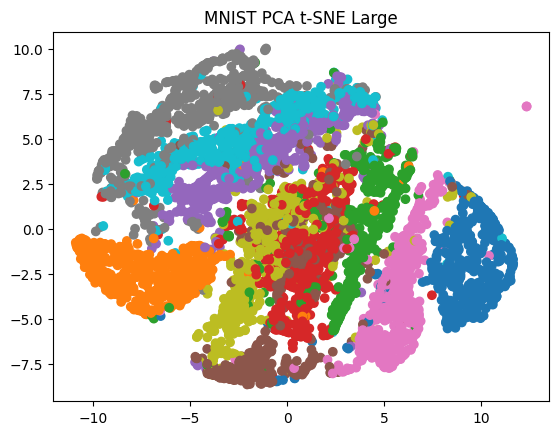

In [22]:
# Example usage:
Y = tsne_eigen(x_train_pca, initialization_method="PCA", T = 500)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_train, cmap='tab10')
plt.title('MNIST PCA t-SNE Large')
plt.show()

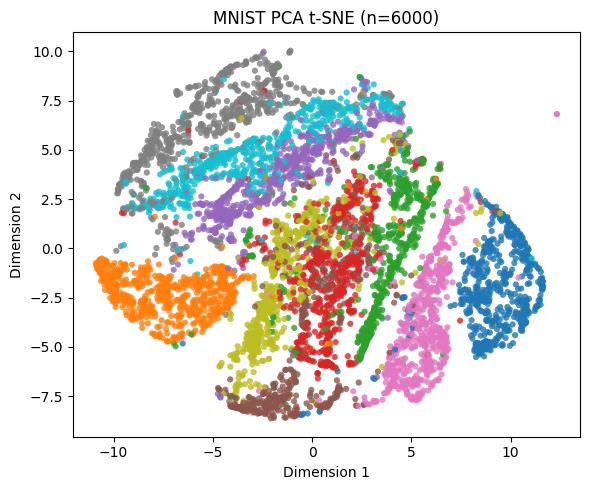

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(
    Y[:, 0], 
    Y[:, 1], 
    c=y_train, 
    cmap='tab10', 
    s=20,
    alpha=0.8,
    edgecolors='none'
)
plt.title('MNIST PCA t-SNE (n=6000)', fontsize=12)
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.tight_layout()
plt.show()


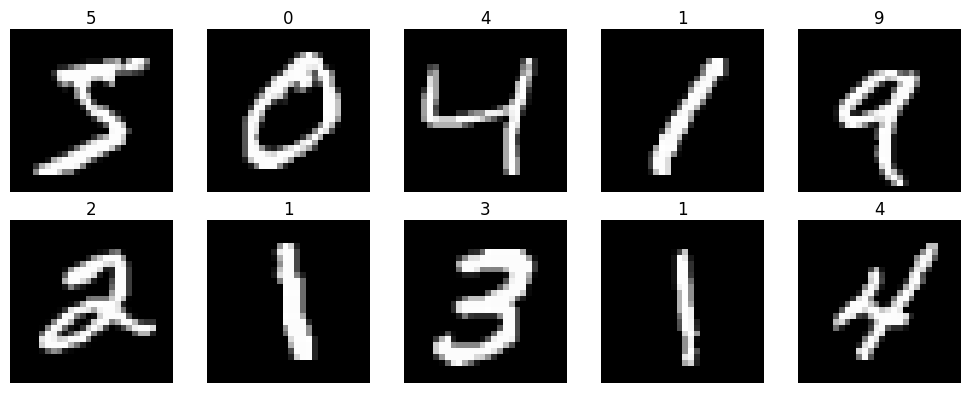

In [14]:
# images of MNIST dataset

import numpy as np
import matplotlib.pyplot as plt

# x_train: (N, 28, 28) or (N, 28, 28, 1)
# y_train: (N,)
def mnist_grid_first10(x_train, y_train=None, save_path="mnist_10_grid.png"):
    # squeeze channel if present
    if x_train.ndim == 4:
        x_show = x_train[:10, :, :, 0]
    else:
        x_show = x_train[:10]

    # choose vmin/vmax so grayscale looks correct whether 0–1 or 0–255
    vmin, vmax = (0, 1) if x_show.dtype != np.uint8 and x_show.max() <= 1.0 else (0, 255)

    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.ravel()
    for i in range(10):
        axes[i].imshow(x_show[i], cmap="gray", vmin=vmin, vmax=vmax)
        if y_train is not None:
            axes[i].set_title(f"{y_train[i]}", fontsize=12, pad=4)
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Example call:
mnist_grid_first10(x_train, y_train, save_path="mnist_first10.png")


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.4846458735744865
Iteration 50: Value of Cost Function is 0.9776737386912495
Iteration 100: Value of Cost Function is 0.7750683206308935
Iteration 150: Value of Cost Function is 0.6816531683671004
Iteration 200: Value of Cost Function is 0.6257841427407331
Iteration 250: Value of Cost Function is 0.5881019897466958
Iteration 300: Value of Cost Function is 0.5607735280523235
Iteration 350: Value of Cost Function is 0.5399645316512233
Iteration 400: Value of Cost Function is 0.5235762433379094
Iteration 450: Value of Cost Function is 0.5103364049588663
Iteration 500: Value of Cost Function is 0.4994120363724123
Iteration 55

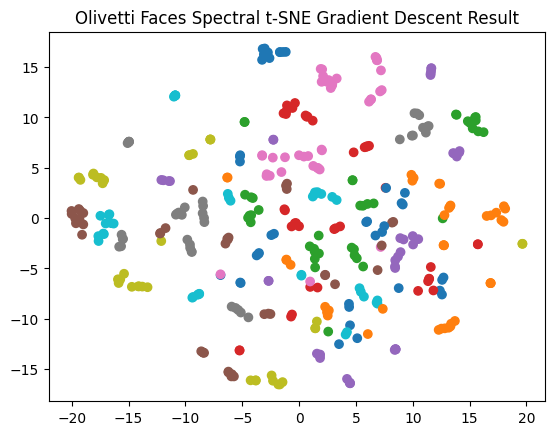

In [35]:
Y = tsne_eigen(X_pca_face, initialization_method="spectral", T = 1000)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_f, cmap='tab10')
plt.title('Olivetti Faces Spectral t-SNE Gradient Descent Result')
plt.show()

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 3.799121991014708
Iteration 50: Value of Cost Function is 2.5108027593697404
Iteration 100: Value of Cost Function is 1.9135751080235948
Iteration 150: Value of Cost Function is 1.6391841987137534
Iteration 200: Value of Cost Function is 1.4661956872892052
Iteration 250: Value of Cost Function is 1.3452516606974214
Iteration 300: Value of Cost Function is 1.2541483108438385
Iteration 350: Value of Cost Function is 1.1822886282053835
Iteration 400: Value of Cost Function is 1.1235890396672854
Iteration 450: Value of Cost Function is 1.0743765062092923
Iteration 500: Value of Cost Function is 1.032353899792071
Iteration 550:

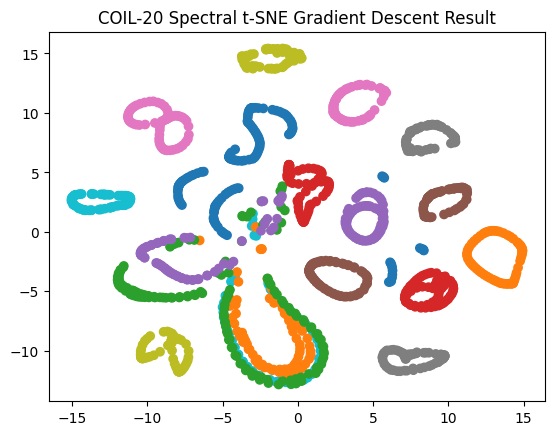

In [36]:
Y = tsne_eigen(X_pca_coil, initialization_method="spectral", T = 1000)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_c, cmap='tab10')
plt.title('COIL-20 Spectral t-SNE Gradient Descent Result')
plt.show()

# Small translations

https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=10734850

### Tangent Distance t-SNE

In [125]:
# Take flat images and divide by 8-bit pixel value
x_train_tangent = x_train_flat / (2**8 - 1)

In [ ]:
from scipy.ndimage import shift


def compute_tangent_vectors(img):
    """Compute horizontal and vertical tangent vectors from a flattened 28x28 image."""
    img = img.reshape(28, 28)
    t_horiz = shift(img, shift=[0, 1], mode='nearest') - shift(img, shift=[0, -1], mode='nearest')
    t_vert  = shift(img, shift=[1, 0], mode='nearest') - shift(img, shift=[-1, 0], mode='nearest')
    return t_horiz.flatten(), t_vert.flatten()


def tangent_distance(x_i, x_j):
    """Compute tangent distance between two flattened 28x28 images."""
    T1, T2 = compute_tangent_vectors(x_j)
    T = np.vstack([T1, T2]).T
    diff = x_i - x_j
    alpha, _, _, _ = np.linalg.lstsq(T, diff, rcond=None)
    x_j_aligned = x_j + T @ alpha
    return np.linalg.norm(x_i - x_j_aligned)


def _grid_search_tangent(dist_vector: np.ndarray, i: int, perplexity: int) -> float:
    """grid_search variant operating on pre-computed tangent distance vectors."""
    result = np.inf
    std_norm = np.std(dist_vector)
    sigma = std_norm
    for sigma_search in np.linspace(0.01 * std_norm, 5 * std_norm, 200):
        p = np.exp(-(dist_vector**2) / (2 * sigma_search**2))
        p[i] = 0
        epsilon = np.nextafter(0, 1)
        p_new = np.maximum(p / (np.sum(p) + epsilon), epsilon)
        H = -np.sum(p_new * np.log2(p_new))
        if np.abs(np.log(perplexity) - H * np.log(2)) < np.abs(result):
            result = np.log(perplexity) - H * np.log(2)
            sigma = sigma_search
    return sigma


def get_tangent_affinities(X: np.ndarray, perplexity: int = 10) -> np.ndarray:
    """Compute p_ij using tangent distance instead of Euclidean distance."""
    n = len(X)
    print("Computing Tangent-Distance Pairwise Affinities...")
    p_ij = np.zeros((n, n))
    for i in range(n):
        dist_vector = np.array([tangent_distance(X[i], X[j]) for j in range(n)])
        sigma_i = _grid_search_tangent(dist_vector, i, perplexity)
        p_ij[i, :] = np.exp(-(dist_vector**2) / (2 * sigma_i**2))
        p_ij[i, i] = 0
        p_ij[i, :] = p_ij[i, :] / np.sum(p_ij[i, :])
    print("Done.")
    return np.maximum(p_ij, np.nextafter(0, 1))


def tsne_tangent(
    X: np.ndarray,
    perplexity: int = 30,
    T: int = 1000,
    eta: int = 100,
    early_exaggeration: int = 1,
    n_dimensions: int = 2,
) -> np.ndarray:
    """t-SNE using tangent distance for high-dimensional affinities."""
    n = len(X)
    p_ij = get_tangent_affinities(X, perplexity)
    p_ij_symmetric = get_symmetric_p_ij(p_ij)

    Y = np.zeros((T, n, n_dimensions))
    Y[0] = np.zeros((n, n_dimensions))
    Y[1] = initialization(X, n_dimensions)

    print("Optimizing Low Dimensional Embedding....")
    for t in range(1, T - 1):
        exagg = early_exaggeration if t < 250 else 1
        q_ij = get_low_dimensional_affinities(Y[t])
        gradient = get_gradient(exagg * p_ij_symmetric, q_ij, Y[t])
        Y[t + 1] = Y[t] - eta * gradient
        if t % 50 == 0 or t == 1:
            cost = np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij))
            print(f"Iteration {t}: Cost = {cost:.4f}")

    print(f"Final Cost = {np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij)):.4f}")
    return Y[-1]

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.6522011523934204
Iteration 50: Value of Cost Function is 1.017814152570626
Iteration 100: Value of Cost Function is 0.8149087466853682
Iteration 150: Value of Cost Function is 0.748296773437652
Iteration 200: Value of Cost Function is 0.713442492799614
Iteration 250: Value of Cost Function is 0.6947361276400121
Iteration 300: Value of Cost Function is 0.682868482350313
Iteration 350: Value of Cost Function is 0.673873153283372
Iteration 400: Value of Cost Function is 0.6671988649427648
Iteration 450: Value of Cost Function is 0.6622520344791094
Iteration 500: Value of Cost Function is 0.6591199945852569
Iteration 550: Value of Cost Function is 0.656648276578571
Iteration 600: Value of Cost Function is 0.6546194061184165
Iteration 650: Value of Cost Function is 0.

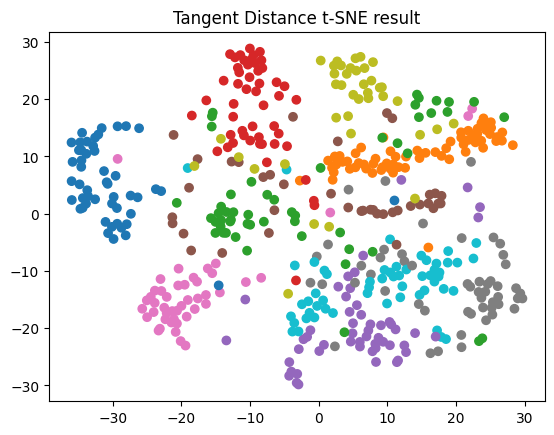

In [127]:
# Example usage:
Y = tsne_tangent(x_train_tangent)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_train, cmap='tab10')
plt.title('Tangent Distance t-SNE result')
plt.show()

### SD t-SNE

Iteration  0
Iteration  1
Iteration  2
Iteration  3
Iteration  4
Iteration  5
Iteration  6
Iteration  7
Iteration  8
Iteration  9
Iteration  10
Iteration  11
Iteration  12
Iteration  13
Iteration  14
Iteration  15
Iteration  16
Iteration  17
Iteration  18
Iteration  19
Iteration  20
Iteration  21
Iteration  22
Iteration  23
Iteration  24
Iteration  25
Iteration  26
Iteration  27
Iteration  28
Iteration  29
Iteration  30
Iteration  31
Iteration  32
Iteration  33
Iteration  34
Iteration  35
Iteration  36
Iteration  37
Iteration  38
Iteration  39
Iteration  40
Iteration  41
Iteration  42
Iteration  43
Iteration  44
Iteration  45
Iteration  46
Iteration  47
Iteration  48
Iteration  49
Iteration  50
Iteration  51
Iteration  52
Iteration  53
Iteration  54
Iteration  55
Iteration  56
Iteration  57
Iteration  58
Iteration  59
Iteration  60
Iteration  61
Iteration  62
Iteration  63
Iteration  64
Iteration  65
Iteration  66
Iteration  67
Iteration  68
Iteration  69
Iteration  70
Iteration  71
It

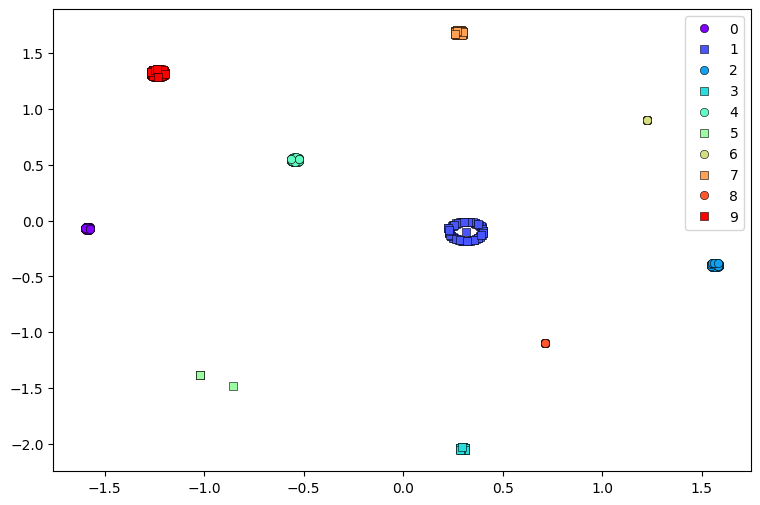

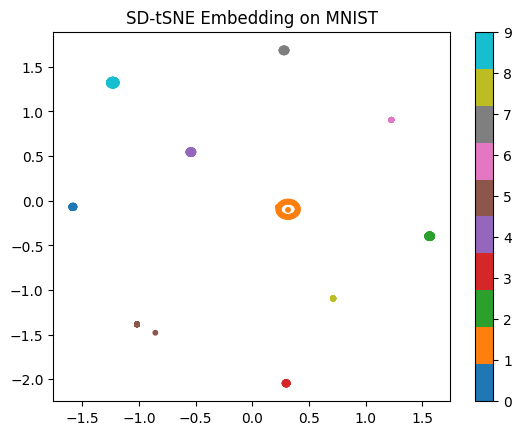

In [ ]:
from SD_tSNE_2D import run_sd_tsne

# Use your own PCA-reduced MNIST
Y = run_sd_tsne(x_train_pca, y_train, perplexity=30, tsne=True)

# Plot it
plt.scatter(Y[:, 0], Y[:, 1], c=y_train, cmap='tab10', s=10)
plt.title("SD-tSNE Embedding on MNIST")
plt.colorbar()
plt.show()


Iteration  0
Iteration  1
Iteration  2
Iteration  3
Iteration  4
Iteration  5
Iteration  6
Iteration  7
Iteration  8
Iteration  9
Iteration  10
Iteration  11
Iteration  12
Iteration  13
Iteration  14
Iteration  15
Iteration  16
Iteration  17
Iteration  18
Iteration  19
Iteration  20
Iteration  21
Iteration  22
Iteration  23
Iteration  24
Iteration  25
Iteration  26
Iteration  27
Iteration  28
Iteration  29
Iteration  30
Iteration  31
Iteration  32
Iteration  33
Iteration  34
Iteration  35
Iteration  36
Iteration  37
Iteration  38
Iteration  39
Iteration  40
Iteration  41
Iteration  42
Iteration  43
Iteration  44
Iteration  45
Iteration  46
Iteration  47
Iteration  48
Iteration  49
Iteration  50
Iteration  51
Iteration  52
Iteration  53
Iteration  54
Iteration  55
Iteration  56
Iteration  57
Iteration  58
Iteration  59
Iteration  60
Iteration  61
Iteration  62
Iteration  63
Iteration  64
Iteration  65
Iteration  66
Iteration  67
Iteration  68
Iteration  69
Iteration  70
Iteration  71
It

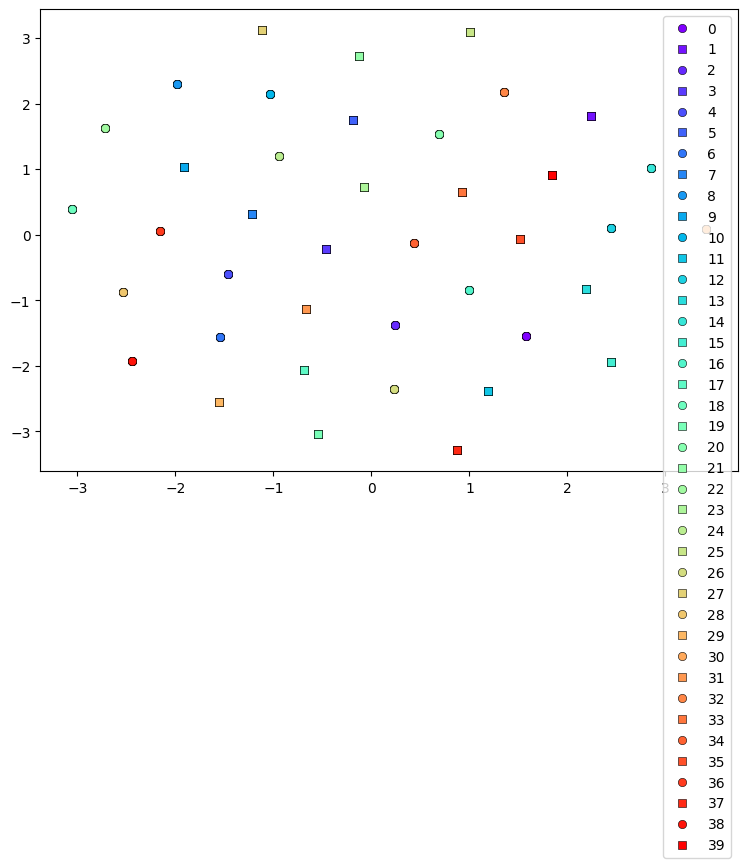

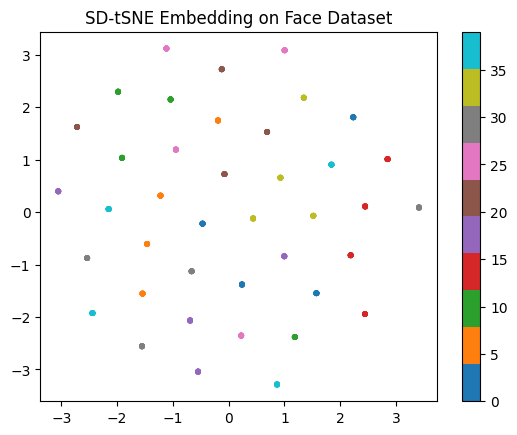

In [103]:
Y_face = run_sd_tsne(X_pca_face, y_f, perplexity=30, tsne=True)

plt.scatter(Y_face[:, 0], Y_face[:, 1], c=y_f, cmap='tab10', s=10)
plt.title("SD-tSNE Embedding on Face Dataset")
plt.colorbar()
plt.show()

Iteration  0
Iteration  1
Iteration  2
Iteration  3
Iteration  4
Iteration  5
Iteration  6
Iteration  7
Iteration  8
Iteration  9
Iteration  10
Iteration  11
Iteration  12
Iteration  13
Iteration  14
Iteration  15
Iteration  16
Iteration  17
Iteration  18
Iteration  19
Iteration  20
Iteration  21
Iteration  22
Iteration  23
Iteration  24
Iteration  25
Iteration  26
Iteration  27
Iteration  28
Iteration  29
Iteration  30
Iteration  31
Iteration  32
Iteration  33
Iteration  34
Iteration  35
Iteration  36
Iteration  37
Iteration  38
Iteration  39
Iteration  40
Iteration  41
Iteration  42
Iteration  43
Iteration  44
Iteration  45
Iteration  46
Iteration  47
Iteration  48
Iteration  49
Iteration  50
Iteration  51
Iteration  52
Iteration  53
Iteration  54
Iteration  55
Iteration  56
Iteration  57
Iteration  58
Iteration  59
Iteration  60
Iteration  61
Iteration  62
Iteration  63
Iteration  64
Iteration  65
Iteration  66
Iteration  67
Iteration  68
Iteration  69
Iteration  70
Iteration  71
It

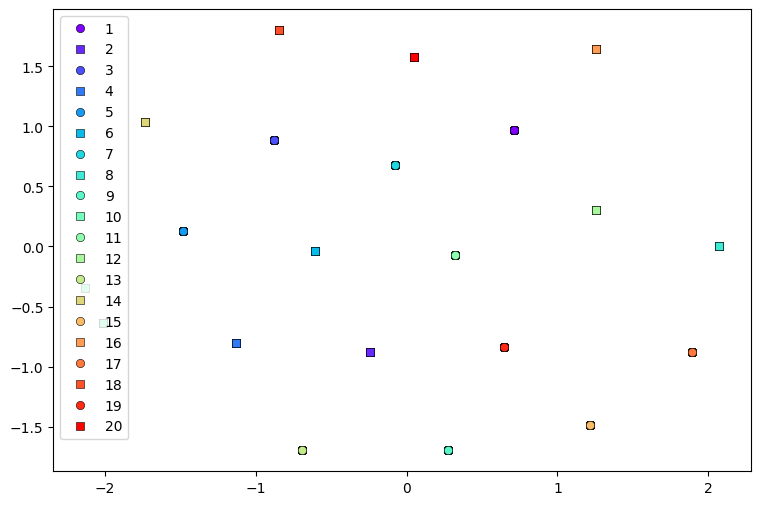

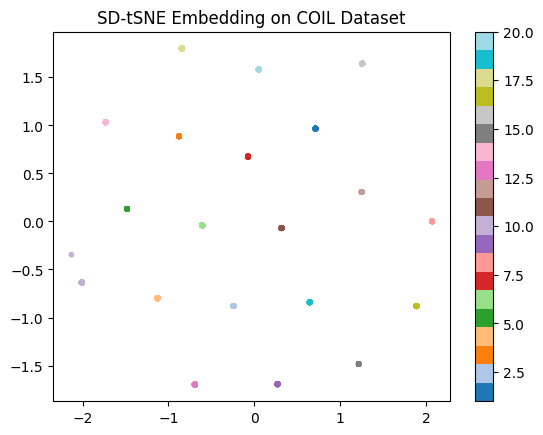

In [104]:
Y_coil = run_sd_tsne(X_pca_coil, y_c, perplexity=30, tsne=True)

plt.scatter(Y_coil[:, 0], Y_coil[:, 1], c=y_c, cmap='tab20', s=10)
plt.title("SD-tSNE Embedding on COIL Dataset")
plt.colorbar()
plt.show()


## p_ij = q_ij

In [ ]:
def get_pq_affinities(X: np.ndarray) -> np.ndarray:
    """Compute p_ij using Student-t kernel: proportional to (1 + 100*||x_i-x_j||^2)^{-1}."""
    n = len(X)
    p_ij = np.zeros((n, n))
    for i in range(n):
        diff = X[i] - X
        norm = np.linalg.norm(diff, axis=1)
        p_ij[i, :] = 1 / (1 + 100 * norm**2)
    np.fill_diagonal(p_ij, 0)
    p_ij = p_ij / np.sum(p_ij)
    return np.maximum(p_ij, np.nextafter(0, 1))


def tsne_pq(
    X: np.ndarray,
    T: int = 1000,
    eta: int = 100,
    early_exaggeration: int = 1,
    n_dimensions: int = 2,
) -> np.ndarray:
    """t-SNE variant where p_ij uses the same Student-t kernel as q_ij (p=q ansatz)."""
    n = len(X)
    p_ij = get_pq_affinities(X)

    Y = np.zeros((T, n, n_dimensions))
    Y[0] = np.zeros((n, n_dimensions))
    Y[1] = initialization(X, n_dimensions)

    print("Optimizing Low Dimensional Embedding....")
    for t in range(1, T - 1):
        exagg = early_exaggeration if t < 250 else 1
        q_ij = get_low_dimensional_affinities(Y[t])
        gradient = get_gradient(exagg * p_ij, q_ij, Y[t])
        Y[t + 1] = Y[t] - eta * gradient
        if t % 50 == 0 or t == 1:
            cost = np.sum(p_ij * np.log(p_ij / q_ij))
            print(f"Iteration {t}: Cost = {cost:.4f}")

    print(f"Final Cost = {np.sum(p_ij * np.log(p_ij / q_ij)):.4f}")
    return Y[-1]

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 0.6735159116666444
Iteration 50: Value of Cost Function is 0.2693688071412037
Iteration 100: Value of Cost Function is 0.22044356292927084
Iteration 150: Value of Cost Function is 0.21698123545438722
Iteration 200: Value of Cost Function is 0.21643506382860667
Iteration 250: Value of Cost Function is 0.2158607020487203
Iteration 300: Value of Cost Function is 0.21529569288828285
Iteration 350: Value of Cost Function is 0.21495932998139713
Iteration 400: Value of Cost Function is 0.21472250423155712
Iteration 450: Value of Cost Function is 0.21454618302641504
Iteration 500: Value of Cost Function is 0.214439844947988
Iteration 550: Value of Cost Function is 0.21435866165095846
Iteration 600: Value of Cost Function is 0.21428519519722394
Iteration 650: Value of Cost Function is 0.2142130247071232
Iteration 700: Value of Cost Function is

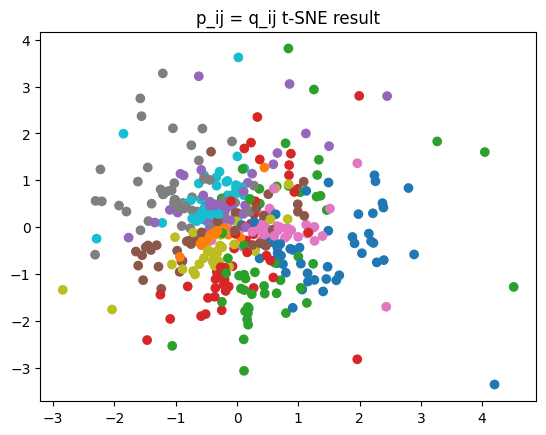

In [152]:
Y = tsne_pq(x_train_pca)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_train, cmap='tab10')
plt.title('p_ij = q_ij t-SNE result')
plt.show()

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.2105286525967232
Iteration 50: Value of Cost Function is 0.7716365204351224
Iteration 100: Value of Cost Function is 0.6929535943176764
Iteration 150: Value of Cost Function is 0.31902903710344593
Iteration 200: Value of Cost Function is 0.12331365941132869
Iteration 250: Value of Cost Function is 0.1230272051342153
Iteration 300: Value of Cost Function is 0.12302556653360969
Iteration 350: Value of Cost Function is 0.12302296686112038
Iteration 400: Value of Cost Function is 0.12302210850219115
Iteration 450: Value of Cost Function is 0.12302175490810967
Iteration 500: Value of Cost Function is 0.12302158616932685
Iteration 550: Value of Cost Function is 0.12302149824805604
Iteration 600: Value of Cost Function is 0.12302144995040032
Iteration 650: Value of Cost Function is 0.12302142255161351
Iteration 700: Value of Cost Function 

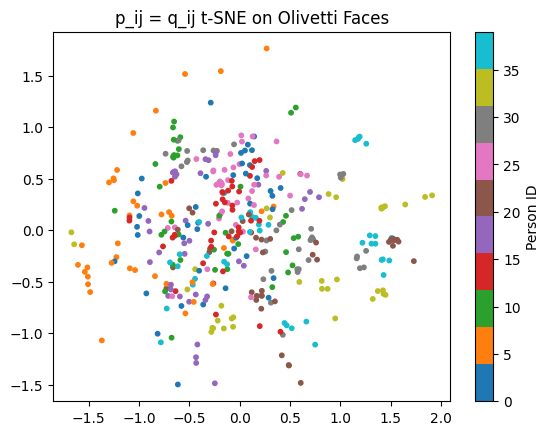

In [142]:
Y = tsne_pq(X_pca_face)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_f, cmap='tab10', s=10)
plt.colorbar(label="Person ID")
plt.title("p_ij = q_ij t-SNE on Olivetti Faces")
plt.show()

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 0.7646391537058925
Iteration 50: Value of Cost Function is 0.5310786624581161
Iteration 100: Value of Cost Function is 0.49609731174192473
Iteration 150: Value of Cost Function is 0.4862797813717688
Iteration 200: Value of Cost Function is 0.4865876403525261
Iteration 250: Value of Cost Function is 0.4930486680451842
Iteration 300: Value of Cost Function is 0.5040463651121215
Iteration 350: Value of Cost Function is 0.5183143769755473
Iteration 400: Value of Cost Function is 0.5350367181995854
Iteration 450: Value of Cost Function is 0.553089557933167
Iteration 500: Value of Cost Function is 0.571340740996527
Iteration 550: Value of Cost Function is 0.5888412779454354
Iteration 600: Value of Cost Function is 0.6054942676899823
Iteration 650: Value of Cost Function is 0.620885520825378
Iteration 700: Value of Cost Function is 0.6344944

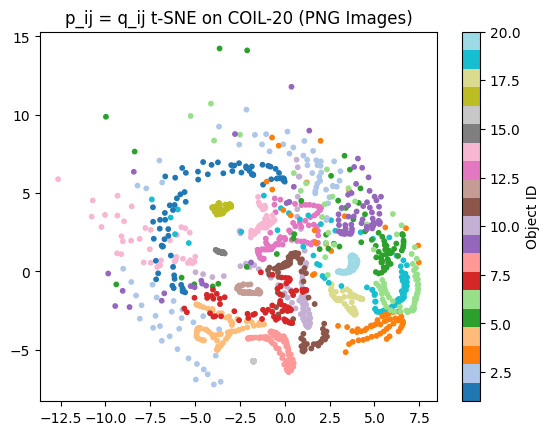

In [143]:
Y = tsne_pq(X_pca_coil)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_c, cmap='tab20', s=10)
plt.colorbar(label="Object ID")
plt.title("p_ij = q_ij t-SNE on COIL-20 (PNG Images)")
plt.show()

## Playing with p_ij

In [ ]:
def pairwise_squared_euclidean(X: np.ndarray) -> np.ndarray:
    """Vectorised pairwise squared Euclidean distance matrix."""
    sum_X = np.sum(np.square(X), axis=1)
    D = -2 * np.dot(X, X.T) + sum_X[:, None] + sum_X[None, :]
    return np.maximum(D, 0)


def compute_single_scale_p_ij(X: np.ndarray, perplexity: int) -> np.ndarray:
    """Single-scale Gaussian affinity matrix via binary search to match perplexity."""
    n = X.shape[0]
    D = pairwise_squared_euclidean(X)
    P = np.zeros((n, n))
    for i in range(n):
        beta_min, beta_max = -np.inf, np.inf
        beta = 1.0
        H_target = np.log(perplexity)
        for _ in range(50):
            P_i = np.exp(-D[i] * beta)
            P_i[i] = 0
            s = np.sum(P_i) or 1e-10
            P_i /= s
            H = -np.sum(P_i * np.log(P_i + 1e-10))
            H_diff = H - H_target
            if abs(H_diff) < 1e-5:
                break
            if H_diff > 0:
                beta_min = beta
                beta = beta * 2 if beta_max == np.inf else (beta + beta_max) / 2
            else:
                beta_max = beta
                beta = beta / 2 if beta_min == -np.inf else (beta + beta_min) / 2
        P[i] = P_i
    P = (P + P.T) / (2 * n)
    return np.maximum(P, np.nextafter(0, 1))


def get_multiscale_affinities(X: np.ndarray, perplexity_list: list = [5, 30, 50]) -> np.ndarray:
    """Average single-scale Gaussian affinities across multiple perplexities."""
    print("Computing Multiscale Pairwise Affinities...")
    p_ij = sum(compute_single_scale_p_ij(X, p) for p in perplexity_list) / len(perplexity_list)
    print("Done.")
    return p_ij


def tsne_p(
    X: np.ndarray,
    perplexity: list = [5, 30, 50],
    T: int = 1000,
    eta: int = 100,
    early_exaggeration: int = 1,
    n_dimensions: int = 2,
) -> np.ndarray:
    """t-SNE with multiscale affinities averaged over multiple perplexities."""
    n = len(X)
    p_ij = get_multiscale_affinities(X, perplexity_list=perplexity)

    Y = np.zeros((T, n, n_dimensions))
    Y[0] = np.zeros((n, n_dimensions))
    Y[1] = initialization(X, n_dimensions)

    print("Optimizing Low Dimensional Embedding....")
    for t in range(1, T - 1):
        exagg = early_exaggeration if t < 250 else 1
        q_ij = get_low_dimensional_affinities(Y[t])
        gradient = get_gradient(exagg * p_ij, q_ij, Y[t])
        Y[t + 1] = Y[t] - eta * gradient
        if t % 50 == 0 or t == 1:
            cost = np.sum(p_ij * np.log(p_ij / q_ij))
            print(f"Iteration {t}: Cost = {cost:.4f}")

    print(f"Final Cost = {np.sum(p_ij * np.log(p_ij / q_ij)):.4f}")
    return Y[-1]

Computing Multiscale Pairwise Affinities...
Completed Multiscale Pairwise Affinities Matrix.
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 2.0108628172421454
Iteration 50: Value of Cost Function is 0.8426596794043184
Iteration 100: Value of Cost Function is 0.7355084862704182
Iteration 150: Value of Cost Function is 0.6884367587759199
Iteration 200: Value of Cost Function is 0.6564652577683788
Iteration 250: Value of Cost Function is 0.6387491769283213
Iteration 300: Value of Cost Function is 0.6274461435359803
Iteration 350: Value of Cost Function is 0.6196195100532446
Iteration 400: Value of Cost Function is 0.612900288813037
Iteration 450: Value of Cost Function is 0.6087632883458118
Iteration 500: Value of Cost Function is 0.605674939608282
Iteration 550: Value of Cost Function is 0.603147500976257
Iteration 600: Value of Cost Function is 0.6009552599800464
Iteration 650: Value of Cost Function is 0.5988595646353543
Iteration 700: Value of Cost Fun

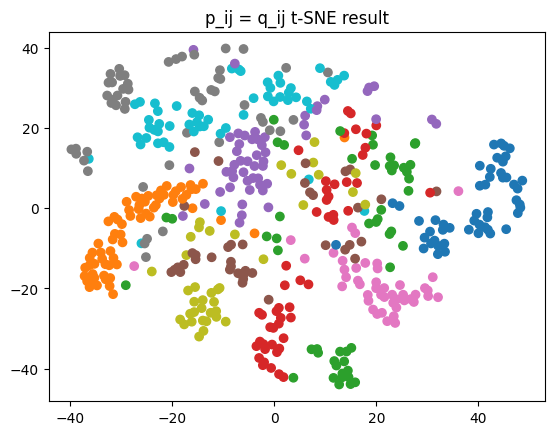

In [145]:
Y = tsne_p(x_train_pca)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_train, cmap='tab10')
plt.title('p_ij = q_ij t-SNE result')
plt.show()

Computing Multiscale Pairwise Affinities...
Completed Multiscale Pairwise Affinities Matrix.
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.8592089734314967
Iteration 50: Value of Cost Function is 0.6638176799995233
Iteration 100: Value of Cost Function is 0.5420059330317282
Iteration 150: Value of Cost Function is 0.49705727307638337
Iteration 200: Value of Cost Function is 0.4683789096121381
Iteration 250: Value of Cost Function is 0.4510105118312076
Iteration 300: Value of Cost Function is 0.4377426124349976
Iteration 350: Value of Cost Function is 0.43070559600187086
Iteration 400: Value of Cost Function is 0.42390372208210586
Iteration 450: Value of Cost Function is 0.4203647144564654
Iteration 500: Value of Cost Function is 0.41794720014993597
Iteration 550: Value of Cost Function is 0.4165080498345125
Iteration 600: Value of Cost Function is 0.4152317986894841
Iteration 650: Value of Cost Function is 0.41445616497137555
Iteration 700: Value of 

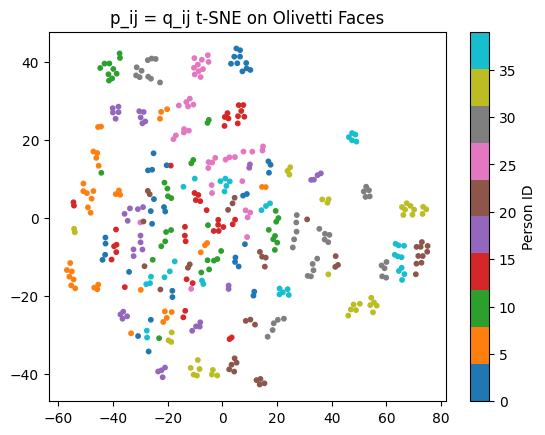

In [146]:
Y = tsne_p(X_pca_face)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_f, cmap='tab10', s=10)
plt.colorbar(label="Person ID")
plt.title("p_ij = q_ij t-SNE on Olivetti Faces")
plt.show()

Computing Multiscale Pairwise Affinities...
Completed Multiscale Pairwise Affinities Matrix.
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.658418073944926
Iteration 50: Value of Cost Function is 1.1517968156816472
Iteration 100: Value of Cost Function is 1.008104852719476
Iteration 150: Value of Cost Function is 0.915275384527281
Iteration 200: Value of Cost Function is 0.8565526508195349
Iteration 250: Value of Cost Function is 0.8178443790989275
Iteration 300: Value of Cost Function is 0.7843612433788123
Iteration 350: Value of Cost Function is 0.7563665820790114
Iteration 400: Value of Cost Function is 0.7356034505062278
Iteration 450: Value of Cost Function is 0.7161752213346911
Iteration 500: Value of Cost Function is 0.6985636460359963
Iteration 550: Value of Cost Function is 0.682920234287322
Iteration 600: Value of Cost Function is 0.6682874473049667
Iteration 650: Value of Cost Function is 0.6554274505799954
Iteration 700: Value of Cost Func

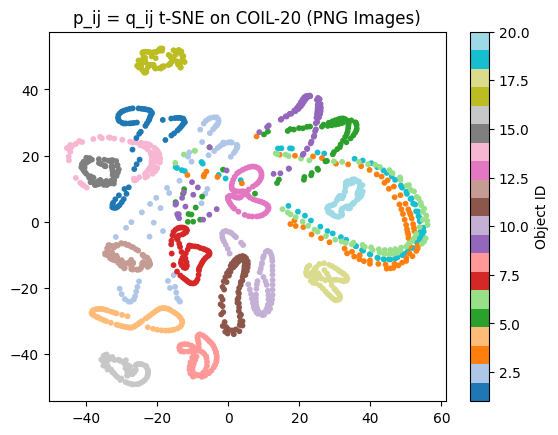

In [147]:
Y = tsne_p(X_pca_coil)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_c, cmap='tab20', s=10)
plt.colorbar(label="Object ID")
plt.title("p_ij = q_ij t-SNE on COIL-20 (PNG Images)")
plt.show()

- write program for UMAP
- set p_ij to q_ij formula
- find a new biology dataset
- create a new dataframe function to enter into tsne and umap algos
    - picks a random pixel (avoids the edge pixels)
    - picks a random direction (U, D, L, R)
    - interchanges the value of the random pixel with adjacent pixel
    - loops over a 1000 times or so...
- create a second new DF function to enter into tsne and umap algos (need to email him about this whole idea...)
    - randomly pick one pixel and then another
    - create a rectangle between the two
    - then take another rectangle of the same size and swap those

# Perturbed Images

## MNIST Perturbed

In [7]:
def perturb_images(X: np.ndarray, num_invert: int, num_aug: int = 9, seed: int = None) -> np.ndarray:
    """
    Applies pixel swaps between neighboring pixels for each image,
    returning original + perturbed copies in proper label alignment.

    Parameters:
    - X (np.ndarray): Input images of shape (n_samples, height, width)
    - num_invert (int): Number of pixel swaps per image
    - num_aug (int): Number of augmentations per image
    - seed (int, optional): Random seed for reproducibility

    Returns:
    - np.ndarray: Augmented images of shape (n_samples * (1 + num_aug), height, width)
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    directions = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}
    h, w = X.shape[1], X.shape[2]
    originals = []
    perturbed = []

    for i in range(len(X)):
        base_img = X[i]
        originals.append(base_img)

        for _ in range(num_aug):
            img = np.copy(base_img)
            for _ in range(num_invert):
                n = np.random.randint(1, h - 1)
                m = np.random.randint(1, w - 1)
                dir_key = random.choice(list(directions.keys()))
                dn, dm = directions[dir_key]
                jn, jm = n + dn, m + dm

                # Swap pixel values
                img[n, m], img[jn, jm] = img[jn, jm], img[n, m]

            perturbed.append(img)

    return np.stack(originals + perturbed)

In [8]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reduce to 100 samples
x_train = x_train[:100]
y_train = y_train[:100]

# Augment images: 9 perturbed versions per original
x_train_perturbed = perturb_images(x_train, num_invert=500, num_aug=9, seed=12)

# Repeat labels for new images
y_train_perturbed = np.tile(y_train, 10)

# Flatten
x_train_perturbed_flat = x_train_perturbed.reshape((x_train_perturbed.shape[0], -1)).astype(np.float32)

# Standardize
scaler = StandardScaler()
x_train_perturbed_scaled = scaler.fit_transform(x_train_perturbed_flat)

# PCA to 40 dimensions
pca = PCA(n_components=40)
x_train_perturbed_pca = pca.fit_transform(x_train_perturbed_scaled)


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.4031397335005429
Iteration 50: Value of Cost Function is 0.630174448745402
Iteration 100: Value of Cost Function is 0.4629790854155101
Iteration 150: Value of Cost Function is 0.3804841518342087
Iteration 200: Value of Cost Function is 0.3261449953840707
Iteration 250: Value of Cost Function is 0.28608852041138133
Iteration 300: Value of Cost Function is 0.2593543225089966
Iteration 350: Value of Cost Function is 0.24040338709577244
Iteration 400: Value of Cost Function is 0.22487631126523483
Iteration 450: Value of Cost Function is 0.21249454155543257
Iteration 500: Value of Cost Function is 0.2028490039402394
Iteration 550: Value of Cost Function is 0.1951847473659771
Iteration 600: Value of Cost Function is 0.1890889825898458
Iteration 650: Value of Cost Funct

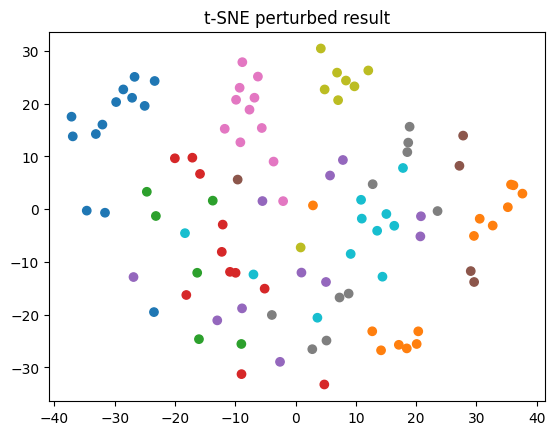

In [10]:
# Example usage:
Y = tsne(x_train_perturbed_pca)

# To visualize:
plt.scatter(Y[:100, 0], Y[:100, 1], c=y_train_perturbed[:100], cmap='tab10')
plt.title('t-SNE perturbed result')
plt.show()

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.0429946279693376
Iteration 50: Value of Cost Function is 0.33629690145328484
Iteration 100: Value of Cost Function is 0.33672909690490466
Iteration 150: Value of Cost Function is 0.33677846268771816
Iteration 200: Value of Cost Function is 0.33678331411324447
Iteration 250: Value of Cost Function is 0.3367837090809038
Iteration 300: Value of Cost Function is 0.3367837415961136
Iteration 350: Value of Cost Function is 0.33678374432412844
Iteration 400: Value of Cost Function is 0.3367837445553916
Iteration 450: Value of Cost Function is 0.3367837445750874
Iteration 500: Value of Cost Function is 0.33678374457676763
Iteration 550: Value of Cost Function is 0.336783744576911
Iteration 600: Value of Cost Function is 0.3367837445769234
Iteration 650: Value of Cost Fun

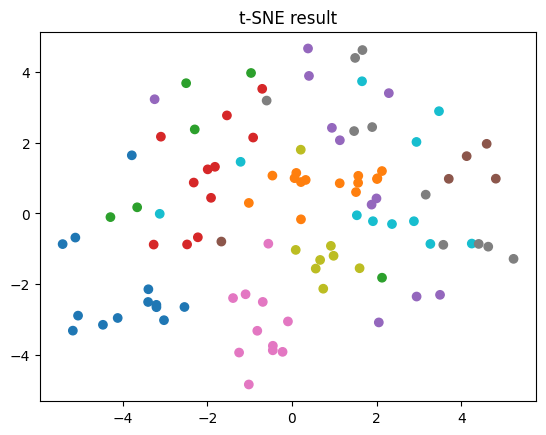

In [35]:
# Example usage:
Y = tsne(x_train_pca)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_train, cmap='tab10')
plt.title('t-SNE result')
plt.show()

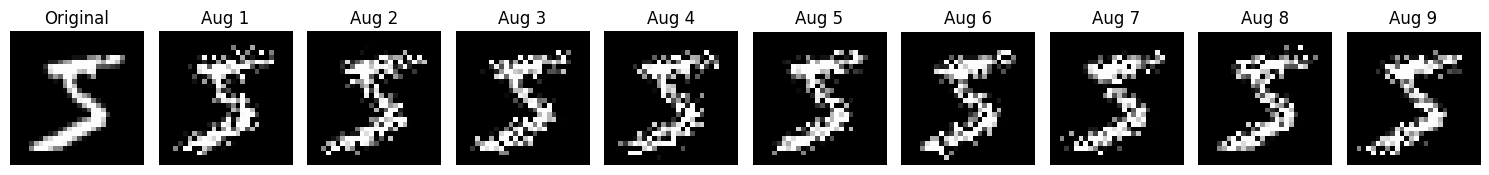

In [39]:
import matplotlib.pyplot as plt

# Pick one digit image to visualize
idx = 0  # index of the image to visualize
num_show = 9  # how many perturbations to display

# Run perturbation only on that one image (repeating it)
sample_image = x_train[idx:idx+1]  # shape (1, 28, 28)
perturbed_samples = perturb_images(sample_image, num_invert=500, num_aug=num_show, seed=42)

# Plot original + perturbations
fig, axes = plt.subplots(1, num_show + 1, figsize=(15, 2))
axes[0].imshow(sample_image[0], cmap='gray')
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(num_show):
    axes[i + 1].imshow(perturbed_samples[i + 1], cmap='gray')  # skip the first (original) image
    axes[i + 1].set_title(f"Aug {i+1}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()


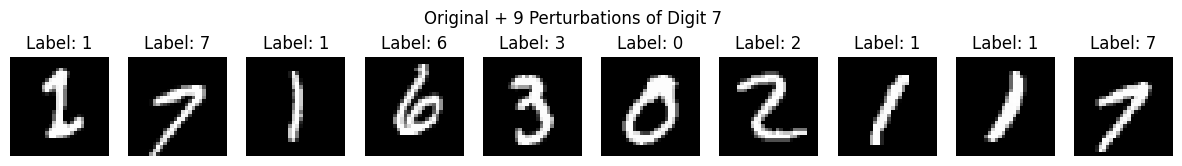

In [45]:
idx = 7
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    k = idx * 10 + i
    axes[i].imshow(x_train_perturbed[k], cmap='gray')
    axes[i].set_title(f"Label: {y_train_perturbed[k]}")
    axes[i].axis("off")
plt.suptitle(f"Original + 9 Perturbations of Digit {idx}")
plt.show()



# Generalizing the perturbation function

In [1]:
def perturb_image(X: np.ndarray, num_invert: int, num_aug: int = 9, seed: int = None) -> np.ndarray:
    """
    Applies pixel swaps between neighboring pixels.
    Returns original images followed by their augmentations,
    grouped per sample: [x0, x0_aug1, ..., x0_aug9, x1, x1_aug1, ..., x1_aug9, ...]
    """
    if seed is not None:
        np.random.seed(seed)

    directions = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)}

    if X.ndim == 3:
        n_samples, h, w = X.shape
        channels = None
    elif X.ndim == 4:
        n_samples, h, w, channels = X.shape
    else:
        raise ValueError("Input images must have shape (n_samples, H, W) or (n_samples, H, W, C)")

    all_outputs = []

    for i in range(n_samples):
        base_img = X[i]
        group = [np.copy(base_img)]

        for _ in range(num_aug):
            img = np.copy(base_img)
            for _ in range(num_invert):
                n = np.random.randint(1, h - 1)
                m = np.random.randint(1, w - 1)
                dn, dm = np.random.choice(list(directions.values()))
                jn, jm = n + dn, m + dm

                if channels is None:
                    img[n, m], img[jn, jm] = img[jn, jm], img[n, m]
                else:
                    img[n, m, :], img[jn, jm, :] = img[jn, jm, :], img[n, m, :]

            group.append(img)

        all_outputs.extend(group)

    return np.stack(all_outputs)


NameError: name 'np' is not defined

In [45]:
def show_group_with_labels(X, y, group_index, group_size=10):
    """
    Plot `group_size` images from X[group_index*group_size : (group_index+1)*group_size],
    with their corresponding labels from y just underneath.
    """
    start = group_index * group_size
    images = X[start:start+group_size]
    labels = y[start:start+group_size]

    fig, axes = plt.subplots(2, group_size, figsize=(1.5*group_size, 3), 
                             gridspec_kw={'height_ratios': [4, 1]})
    for i in range(group_size):
        # top row: the image
        ax_img = axes[0, i]
        ax_img.imshow(images[i], cmap='gray')
        ax_img.axis('off')

        # bottom row: the label
        ax_lbl = axes[1, i]
        ax_lbl.text(0.5, 0.5, str(labels[i]),
                    ha='center', va='center', fontsize=12)
        ax_lbl.axis('off')

    plt.tight_layout()
    plt.show()

## MNIST

In [67]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reduce to 100 samples
x_train = x_train[:200]
y_train = y_train[:200]

# Augment images: 9 perturbed versions per original
num_aug = 9
x_train_perturbed = perturb_image(x_train, num_invert=500, num_aug=num_aug, seed=12)

# Correctly repeat labels for new images:
y_train_perturbed = np.repeat(y_train, 1 + num_aug)  # shape = (100 * 10,)

# Then continue with flatten / scale / PCA...
x_train_perturbed_flat = x_train_perturbed.reshape((x_train_perturbed.shape[0], -1)).astype(np.float32)
scaler = StandardScaler()
x_train_perturbed_scaled = scaler.fit_transform(x_train_perturbed_flat)
pca = PCA(n_components=40)
x_train_perturbed_pca = pca.fit_transform(x_train_perturbed_scaled)


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.9166160337543652
Iteration 50: Value of Cost Function is 1.281169950778518
Iteration 100: Value of Cost Function is 1.0382722291575759
Iteration 150: Value of Cost Function is 0.880669339336584
Iteration 200: Value of Cost Function is 0.7696774214467536
Iteration 250: Value of Cost Function is 0.6876232427725576
Iteration 300: Value of Cost Function is 0.6243696532075634
Iteration 350: Value of Cost Function is 0.5739678689525598
Iteration 400: Value of Cost Function is 0.5323654561702452
Iteration 450: Value of Cost Function is 0.4971702196034906
Iteration 500: Value of Cost Function is 0.467134728520809
Iteration 550: Value of Cost Function is 0.4414634432850716
Iteration 600: Value of Cost Function is 0.4194032072408418
Iteration 650: Value of Cost Function is

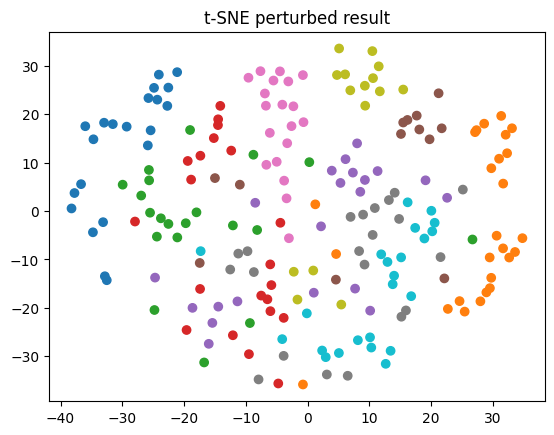

In [63]:
# Example usage:
Y = tsne(x_train_perturbed_pca)

# To visualize:
plt.scatter(Y[::10,0], Y[::10,1], c=y_train_perturbed[::10], cmap='tab10')
plt.title('t-SNE perturbed result')
plt.show()

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.3070174194207738
Iteration 50: Value of Cost Function is 0.4905147883929306
Iteration 100: Value of Cost Function is 0.4136169558107147
Iteration 150: Value of Cost Function is 0.4026196616127272
Iteration 200: Value of Cost Function is 0.40061360445616945
Iteration 250: Value of Cost Function is 0.3989884640939067
Iteration 300: Value of Cost Function is 0.39792616167680545
Iteration 350: Value of Cost Function is 0.3970946624090185
Iteration 400: Value of Cost Function is 0.3959656957837225
Iteration 450: Value of Cost Function is 0.3958137239001681
Iteration 500: Value of Cost Function is 0.3957650953998004
Iteration 550: Value of Cost Function is 0.3957499502274724
Iteration 600: Value of Cost Function is 0.395743387884179
Iteration 650: Value of Cost Functio

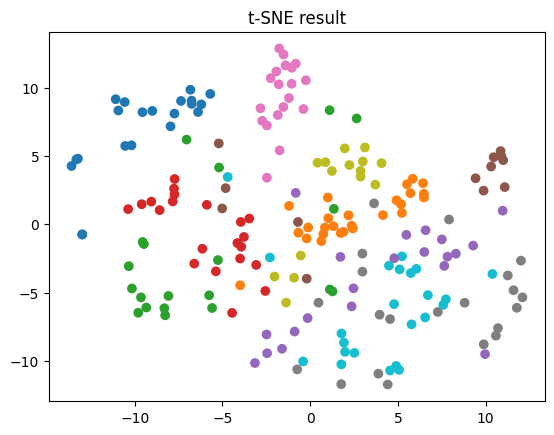

In [68]:
x_train_flat = x_train.reshape((x_train.shape[0], -1)).astype(np.float32)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
pca = PCA(n_components=40)
x_train_pca = pca.fit_transform(x_train_scaled)

# Example usage:
Y = tsne(x_train_pca)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_train, cmap='tab10')
plt.title('t-SNE result')
plt.show()

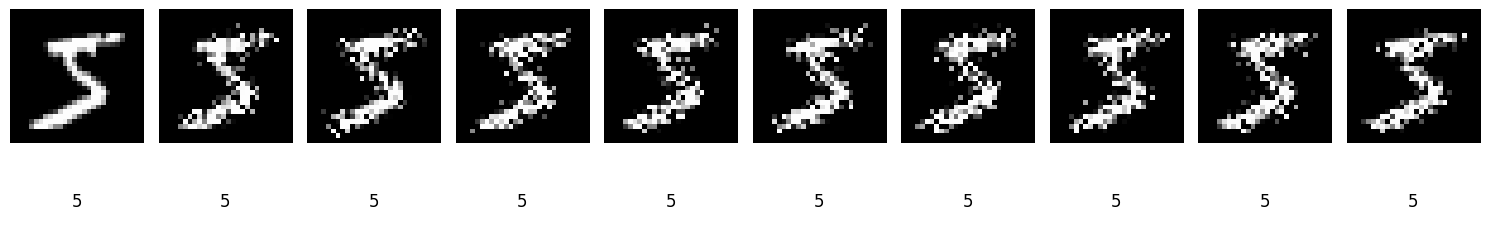

In [57]:
show_group_with_labels(x_train_perturbed, y_train_perturbed, group_index=0)


## Faces

In [20]:
# Load Olivetti Faces
faces = fetch_olivetti_faces(shuffle=False, random_state=1)
X_face = faces.data
y_face = faces.target.copy()

# Sample 5 images per class (40 classes → 200 total images)
samples_per_class = 5
unique_classes = np.unique(y_face)  # this should give [0, 1, ..., 39]

X_balanced = []
y_balanced_grouped = []

for cls in unique_classes:
    idx = np.where(y_face == cls)[0]
    chosen = np.random.choice(idx, samples_per_class, replace=False)
    
    for i in range(samples_per_class):
        X_balanced.append(X_face[chosen[i]])
        y_balanced_grouped.append(cls)

X_balanced = np.array(X_balanced)
y_balanced_grouped = np.array(y_balanced_grouped)

X_face_reshaped = X_balanced.reshape(-1, 64, 64)
X_face_perturbed = perturb_image(X_face_reshaped, num_invert=500, num_aug=9, seed=42)
y_face_perturbed = np.repeat(y_balanced_grouped, 10)

# Flatten and apply PCA
X_face_flat = X_face_perturbed.reshape(X_face_perturbed.shape[0], -1)
X_face_scaled = StandardScaler().fit_transform(X_face_flat)
X_face_pca = PCA(n_components=40).fit_transform(X_face_scaled)

In [37]:
Y = tsne_eigen(X_face_pca)

# Step 2: Extract original 200 (1 per group)
original_indices = np.arange(0, 2000, 10)  # Every 10th image = original
Y_originals = Y[original_indices]
y_originals = y_face_perturbed[original_indices]

# Step 3: Plot
plt.figure(figsize=(8, 6))
plt.scatter(Y_originals[:, 0], Y_originals[:, 1], c=y_originals, cmap='nipy_spectral', s=30)
plt.colorbar(label='Face ID')
plt.title('t-SNE on Perturbed Olivetti Faces')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.4359957906525636
Iteration 50: Value of Cost Function is 0.5904731625721499
Iteration 100: Value of Cost Function is 0.5077555009400999
Iteration 150: Value of Cost Function is 0.4891130181217865
Iteration 200: Value of Cost Function is 0.47850108186049933
Iteration 250: Value of Cost Function is 0.47185504512982757
Iteration 300: Value of Cost Function is 0.46714140255648195
Iteration 350: Value of Cost Function is 0.46077414506071107
Iteration 400: Value of Cost Function is 0.45852974572239225
Iteration 450: Value of Cost Function is 0.45719574760005244
Iteration 500: Value of Cost Function is 0.45430557902790325
Iteration 550: Value of Cost Function is 0.4530094340800751
Iteration 600: Value of Cost Function is 0.4511368070324707
Iteration 650: Value of Cost F

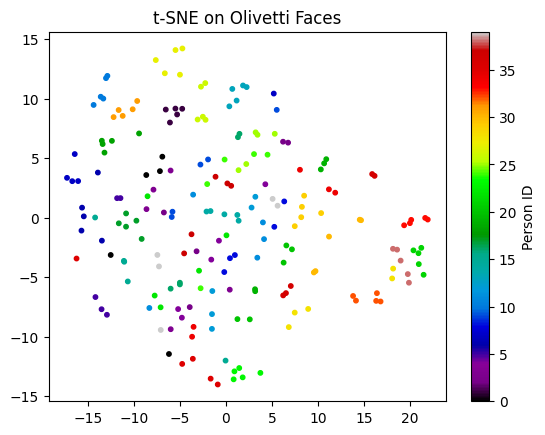

In [61]:
X_flat_face = X_face_reshaped.reshape(X_face_reshaped.shape[0], -1)
X_scaled_face = StandardScaler().fit_transform(X_flat_face)
X_pca_face = PCA(n_components=40).fit_transform(X_scaled_face)

# Example usage:
Y = tsne(X_pca_face)

# To visualize:
plt.scatter(Y[:200, 0], Y[:200, 1], c=y_balanced_grouped[:200], cmap='nipy_spectral', s=10)
plt.colorbar(label="Person ID")
plt.title("t-SNE on Olivetti Faces")
plt.show()

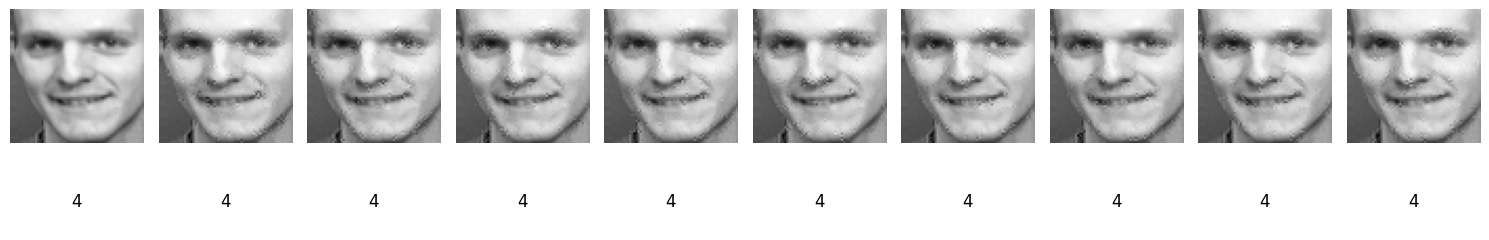

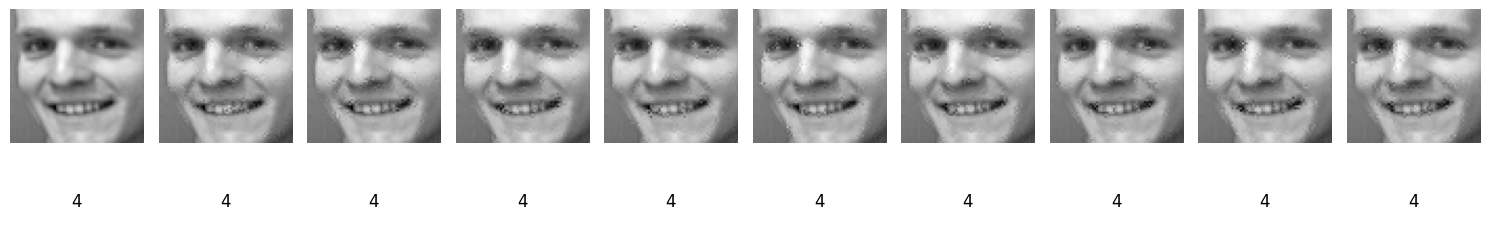

In [46]:
# Example: show first two groups
show_group_with_labels(X_face_perturbed, y_face_perturbed, group_index=20)
show_group_with_labels(X_face_perturbed, y_face_perturbed, group_index=21)


## COIL-20

In [42]:
from sklearn.utils import shuffle

# Load COIL-20 (assumes grayscale .png images like obj1_1.png)
path = r'C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\coil-20-proc\coil-20-proc'

X_coil = []
y_coil = []

for file in sorted(os.listdir(path)):
    if file.endswith(".png"):
        label = int(file.split("_")[0].replace("obj", ""))
        img = Image.open(os.path.join(path, file)).convert("L").resize((32, 32))
        X_coil.append(np.array(img))
        y_coil.append(label)

X_coil = np.array(X_coil)
y_coil = np.array(y_coil)

X_coil, y_coil = shuffle(X_coil, y_coil, random_state=42)
X_coil = X_coil[:500]
y_coil = y_coil[:500]

# Apply perturbation (e.g., 300 swaps per image, 0 augmentations)
X_coil_perturbed = perturb_image(X_coil, num_invert=300, num_aug=4, seed=24)

y_coil_perturbed = np.repeat(y_coil, 5)

# Flatten and normalize
X_coil_flat = X_coil_perturbed.reshape(X_coil_perturbed.shape[0], -1)

scaler_coil = StandardScaler()
X_coil_scaled = scaler_coil.fit_transform(X_coil_flat)

pca_coil = PCA(n_components=40)
X_coil_pca = pca_coil.fit_transform(X_coil_scaled)


Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.3935022396939722
Iteration 50: Value of Cost Function is 0.9520858475672739
Iteration 100: Value of Cost Function is 0.8113478376986504
Iteration 150: Value of Cost Function is 0.7298765836705501
Iteration 200: Value of Cost Function is 0.6701593979966802
Iteration 250: Value of Cost Function is 0.6223472384081069
Iteration 300: Value of Cost Function is 0.5881106662464363
Iteration 350: Value of Cost Function is 0.5588747447588295
Iteration 400: Value of Cost Function is 0.5329590884700096
Iteration 450: Value of Cost Function is 0.5101791911255467
Iteration 500: Value of Cost Function is 0.4897927832604118
Iteration 550: Value of Cost Function is 0.47238118564240306
Iteration 600: Value of Cost Function is 0.45705320024020224
Iteration 650: Value of Cost Functi

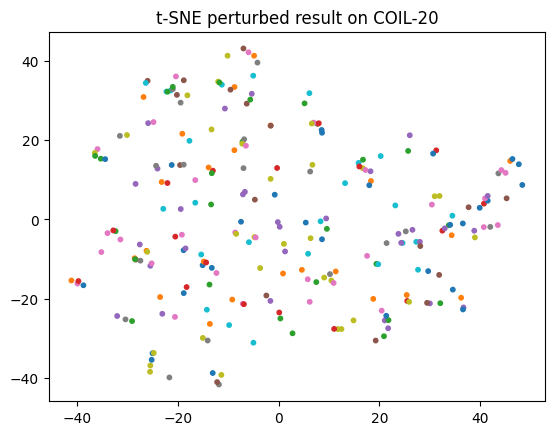

In [34]:
# Example usage:
Y = tsne(X_coil_pca)

original_idxs = np.arange(0, Y.shape[0], 10)
Y_orig = Y[original_idxs]
y_orig = y_coil_perturbed[original_idxs] 

# To visualize:
plt.scatter(Y_orig[:, 0], Y_orig[:, 1], c=y_orig, cmap='tab10', s = 10)
plt.title('t-SNE perturbed result on COIL-20')
plt.show()

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.1294389935434785
Iteration 50: Value of Cost Function is 0.4780549443610066
Iteration 100: Value of Cost Function is 0.4111855456177803
Iteration 150: Value of Cost Function is 0.38126390808256855
Iteration 200: Value of Cost Function is 0.3578318396072015
Iteration 250: Value of Cost Function is 0.33863162313345085
Iteration 300: Value of Cost Function is 0.3270549651777002
Iteration 350: Value of Cost Function is 0.319510520927755
Iteration 400: Value of Cost Function is 0.3149583341352355
Iteration 450: Value of Cost Function is 0.3112254795002801
Iteration 500: Value of Cost Function is 0.30803656173662153
Iteration 550: Value of Cost Function is 0.3050652883450212
Iteration 600: Value of Cost Function is 0.30249062082887873
Iteration 650: Value of Cost Funct

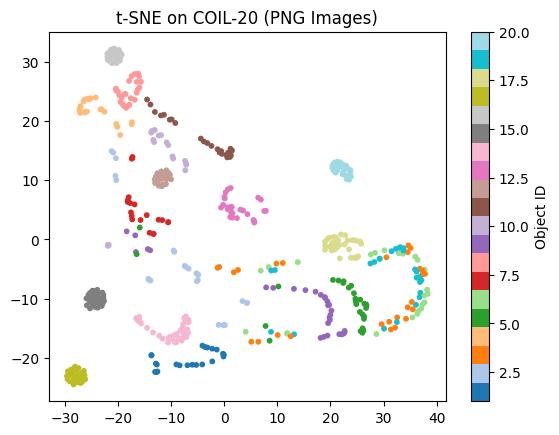

In [59]:
X_flat_coil = X_coil.reshape(X_coil.shape[0], -1)

coil_scaler = StandardScaler()
X_scaled_coil = coil_scaler.fit_transform(X_flat_coil)

X_coil_pca = PCA(n_components=40)
X_pca_coil = X_coil_pca.fit_transform(X_scaled_coil)

# Example usage:
Y = tsne(X_pca_coil)

# To visualize:
plt.scatter(Y[:, 0], Y[:, 1], c=y_coil, cmap='tab20', s=10)
plt.colorbar(label="Object ID")
plt.title("t-SNE on COIL-20 (PNG Images)")
plt.show()

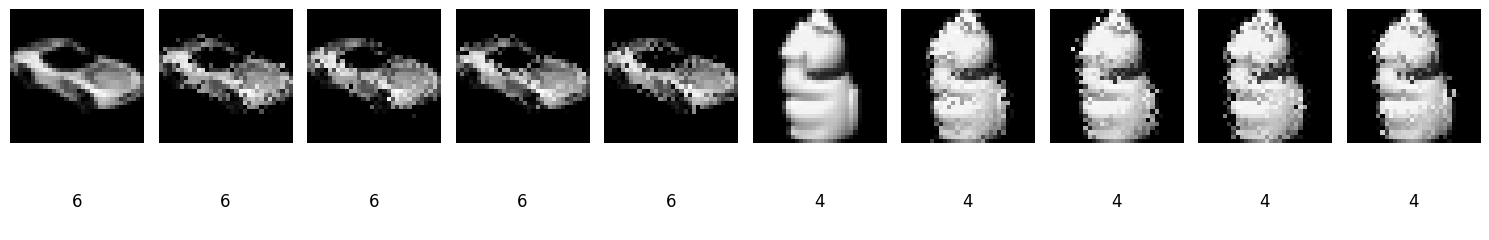

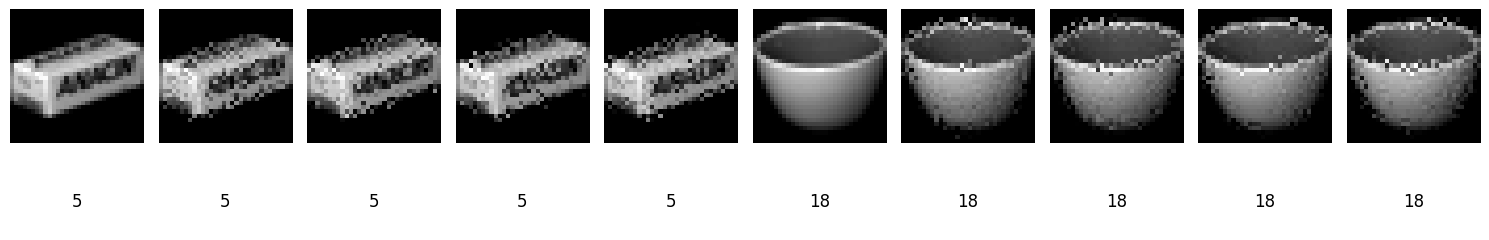

In [44]:
show_group_with_labels(X_coil_perturbed, y_coil_perturbed, group_index=10)
show_group_with_labels(X_coil_perturbed, y_coil_perturbed, group_index=11)

## y = x Line

In [31]:
n_points = 100
x = np.linspace(-10, 10, n_points)
y = x.copy()
X_line = np.vstack([x, y]).T  # shape (100, 2)


# Step 2: Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_line)

# Step 3: PCA (optional for t-SNE, just for compatibility)
pca = PCA(n_components=2)
X_pca_line = pca.fit_transform(X_scaled)

In [34]:
Y = tsne_eigen(X_pca_line)

# Step 5: Visualize
plt.scatter(Y[:, 0], Y[:, 1], c=np.arange(n_points), cmap='viridis', s=25)
plt.colorbar(label="Point Index")
plt.title("t-SNE on Artificial Line y = x")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.show()

# final request

In [ ]:
x_train_pca, y_train = load_mnist(n_samples=60000, pca_components=40)


def run_tsne_plot(run_idx, rng, n_samples=500, outdir="tsne_runs", title_prefix="laplacian t-SNE"):
    os.makedirs(outdir, exist_ok=True)
    idx = rng.choice(x_train_pca.shape[0], size=n_samples, replace=False)
    X = x_train_pca[idx]
    y = y_train[idx]
    seed_for_tsne = int(rng.integers(0, 2**31 - 1))
    try:
        Y = tsne_eigen(X, initialization_method="laplacian", T=1000, random_state=seed_for_tsne)
    except TypeError:
        Y = tsne_eigen(X, initialization_method="laplacian", T=1000)
    plt.figure(figsize=(6, 5))
    plt.scatter(Y[:, 0], Y[:, 1], c=y, s=6, cmap="tab10")
    plt.title(f"{title_prefix} — run {run_idx + 1}")
    plt.xticks([]); plt.yticks([])
    fname = os.path.join(outdir, f"mnist_tsne_laplacian_run_{run_idx + 1:02d}.png")
    plt.savefig(fname, dpi=200, bbox_inches="tight")
    plt.close()
    return fname


master_rng = np.random.default_rng(12345)
saved = [run_tsne_plot(i, np.random.default_rng(master_rng.integers(0, 2**31 - 1))) for i in range(10)]
print("Saved files:")
for f in saved:
    print(f)

In [ ]:
coil_path = r'C:\Users\wpbro\OneDrive\Documents\Stat 303-1\Workspace\Math Research\coil-20-proc\coil-20-proc'
X_pca_coil, y_c = load_coil20(data_dir=coil_path, pca_components=40)


def run_tsne_plot(run_idx, rng, outdir="tsne_runs", title_prefix="spectral t-SNE"):
    os.makedirs(outdir, exist_ok=True)
    n_samples = min(500, X_pca_coil.shape[0])
    idx = rng.choice(X_pca_coil.shape[0], size=n_samples, replace=False)
    X = X_pca_coil[idx]
    y = y_c[idx]
    seed_for_tsne = int(rng.integers(0, 2**31 - 1))
    try:
        Y = tsne_eigen(X, initialization_method="spectral", T=1000, random_state=seed_for_tsne)
    except TypeError:
        Y = tsne_eigen(X, initialization_method="spectral", T=1000)
    plt.figure(figsize=(6, 5))
    plt.scatter(Y[:, 0], Y[:, 1], c=y, s=6, cmap="tab10")
    plt.title(f"{title_prefix} — run {run_idx + 1}")
    plt.xticks([]); plt.yticks([])
    fname = os.path.join(outdir, f"coil_tsne_spectral_run_{run_idx + 1:02d}.png")
    plt.savefig(fname, dpi=200, bbox_inches="tight")
    plt.close()
    return fname


master_rng = np.random.default_rng(12345)
saved = [run_tsne_plot(i, np.random.default_rng(master_rng.integers(0, 2**31 - 1))) for i in range(10)]
print("Saved files:")
for f in saved:
    print(f)